<a href="https://colab.research.google.com/github/Kashishkewat/python_practice/blob/main/day30_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Softmax Regression and Multinomial Logistic Regression**

In [ ]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df=sns.load_dataset("iris")

In [ ]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df["species"]=encoder.fit_transform(df["species"])

In [ ]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
df=df[['sepal_length','petal_length','species']]

In [ ]:
df.head()

,sepal_length,petal_length,species
0,5.1,1.4,0
1,4.9,1.4,0
2,4.7,1.3,0
3,4.6,1.5,0
4,5.0,1.4,0


In [ ]:
X=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [ ]:
clf=LogisticRegression(multi_class='multinomial')
clf.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='multinomial')

In [ ]:
y_pred=clf.predict(X_test)

In [ ]:
print(accuracy_score(y_test,y_pred))

0.9666666666666667


In [ ]:
from sklearn.metrics import confusion_matrix
pd.DataFrame(confusion_matrix(y_test,y_pred))

,0,1,2
0,14,0,0
1,0,7,1
2,0,0,8


In [ ]:
#prediction
query=np.array([[3.4,2.7]])
clf.predict_proba(query)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[7.25865651e-01, 2.73720718e-01, 4.13631316e-04]])

In [ ]:
clf.predict(query)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


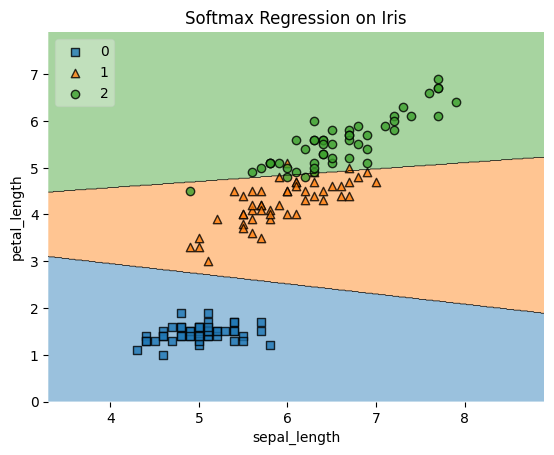

In [ ]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X.values,y.values,clf,legend=2)
plt.xlabel("sepal_length")
plt.ylabel("petal_length")
plt.title("Softmax Regression on Iris")
plt.show()

# **Polynomial Logistic Regression**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving ushape.csv to ushape (1).csv


In [ ]:
df=pd.read_csv("ushape.csv")

In [ ]:
df.head()

,X,Y,class
0,0.031595,0.986988,0.0
1,2.115098,-0.046244,1.0
2,0.882490,-0.075756,0.0
3,-0.055144,-0.037332,1.0
4,0.829545,-0.539321,1.0


In [ ]:
X=df.iloc[:,0:2].values
y=df.iloc[:,-1].values

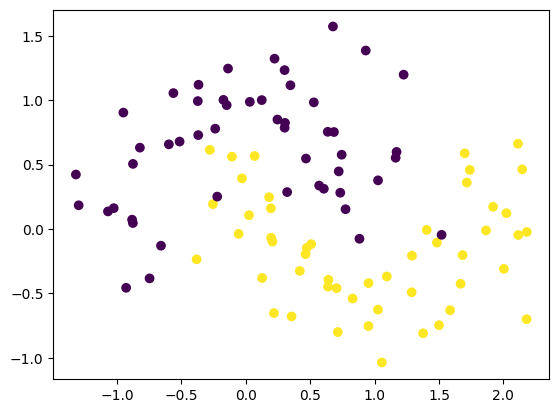

In [ ]:
plt.scatter(X[:,0],X[:,1],c=y)

In [ ]:
from sklearn.linear_model import LogisticRegression
clf=LogisticRegression()
clf.fit(X,y)

LogisticRegression()

<Axes: >

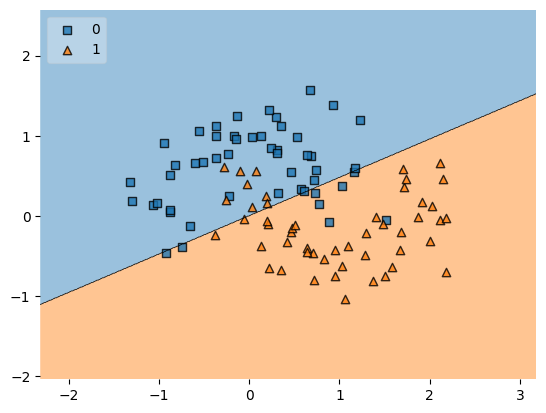

In [ ]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype("int"),clf,legend=2)

In [ ]:
from sklearn.model_selection import cross_val_score
np.mean(cross_val_score(clf,X,y,scoring='accuracy',cv=10))

np.float64(0.8300000000000001)

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=3,include_bias=False)
X_poly=poly.fit_transform(X)

In [ ]:
clf1=LogisticRegression()
np.mean(cross_val_score(clf1,X_poly,y,scoring='accuracy',cv=10))

np.float64(0.9)

In [ ]:
def plot_decision_boundary(X,y,degree=1):
  ploy=PolynomialFeatures(degree=degree)
  X_trf=ploy.fit_transform(X)
  clf2=LogisticRegression()
  clf2.fit(X_trf,y)
  accuracy=np.mean(cross_val_score(clf2,X_trf,y,scoring="accuracy",cv=10))
  a=np.arange(start=X[:,0].min()-1,stop=X[:,0].max()+1,step=0.01)
  b=np.arange(start=X[:,1].min()-1,stop=X[:,1].max()+1,step=0.01)
  XX,YY=np.meshgrid(a,b)
  input_array=np.array([XX.ravel(),YY.ravel()]).T
  labels=clf2.predict(ploy.transform(input_array))
  plt.contourf(XX,YY,labels.reshape(XX.shape),alpha=0.5)
  plt.scatter(X[:,0],X[:,1],c=y)
  plt.title("Degree={},accuracy is {}".format(degree,np.round(accuracy,4)))

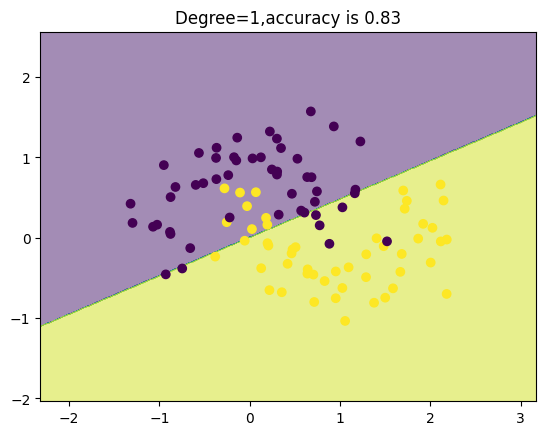

In [ ]:
plot_decision_boundary(X,y)

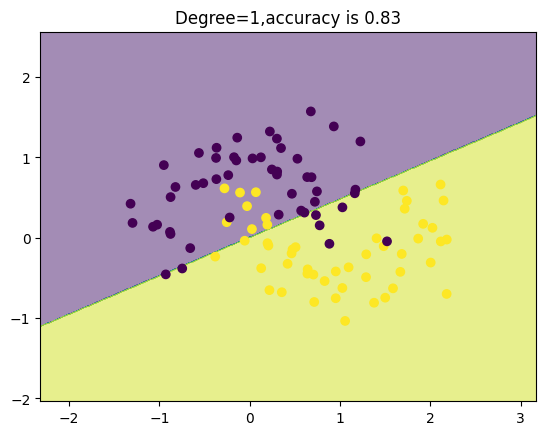

In [ ]:
plot_decision_boundary(X,y,degree=1)

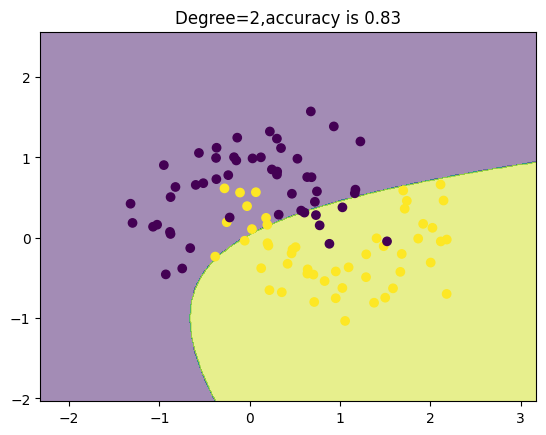

In [ ]:
plot_decision_boundary(X,y,degree=2)

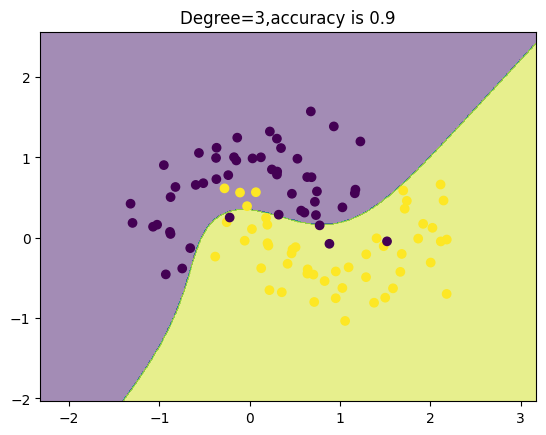

In [ ]:
plot_decision_boundary(X,y,degree=3)

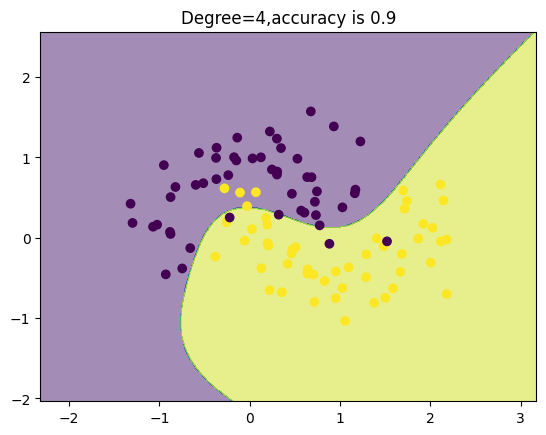

In [ ]:
plot_decision_boundary(X,y,degree=4)

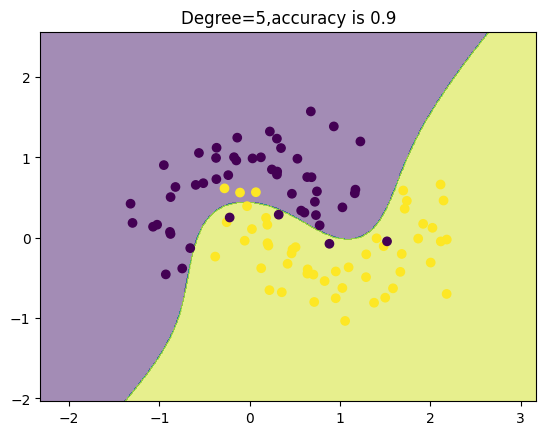

In [ ]:
plot_decision_boundary(X,y,degree=5)

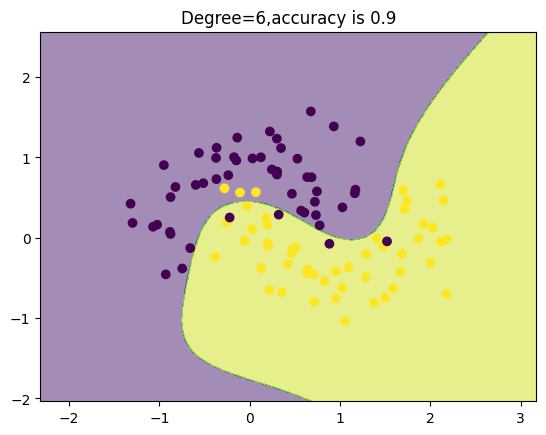

In [ ]:
plot_decision_boundary(X,y,degree=6)